**1. Import Libraries**




In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score
)

import pickle

**2. Load Dataset**

  Dataset load + basic check





In [2]:
df = pd.read_csv("Crop_recommendation.csv")

In [3]:
print("Shape:", df.shape)

Shape: (2200, 8)


In [4]:
print(df.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


# **3. Data Cleaning**

  Missing values handle

In [34]:
for col in df.select_dtypes(include=np.number).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = np.clip(df[col], lower, upper)

**4. Encode Target**

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# **5. EDA**

 i.) Basic Data Understanding

In [21]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Shape of dataset: (2200, 8)

Columns:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label            int64
dtype: object

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Statistical Summary:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.0

ii.) Correlation Heatmap

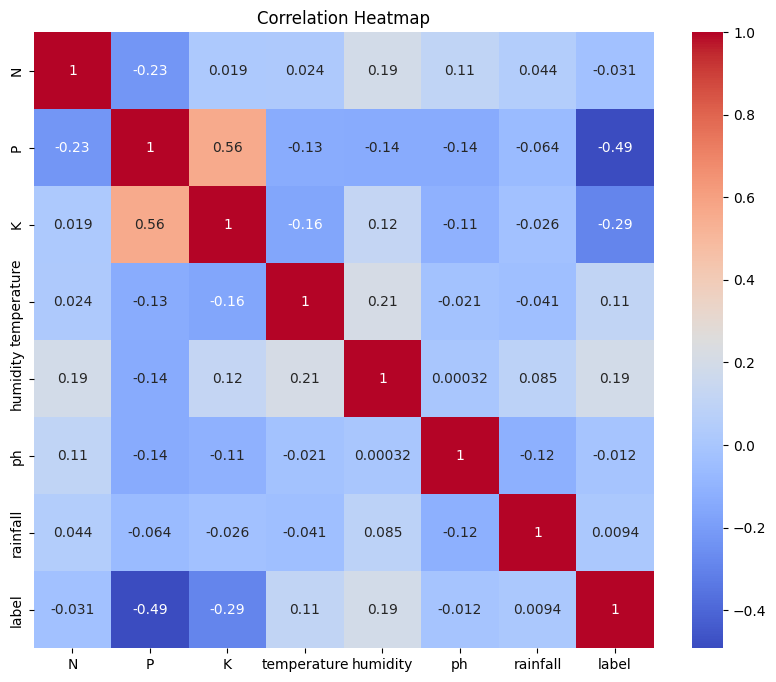

In [54]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')

iii.) Distribution of Features

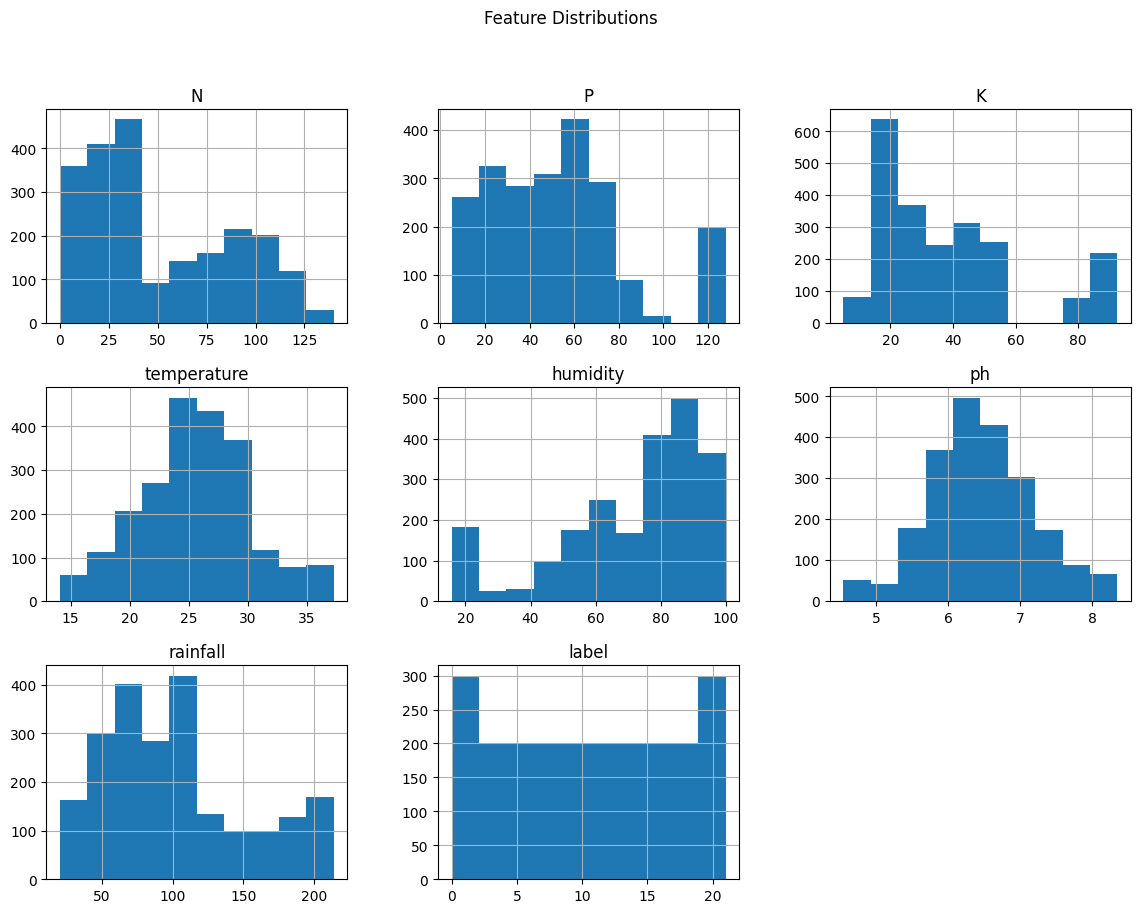

In [57]:
df.hist(figsize=(14,10))
plt.suptitle("Feature Distributions")


plt.savefig("histogram.png", dpi=300, bbox_inches='tight')

plt.show()

iv.) Target Variable Distribution

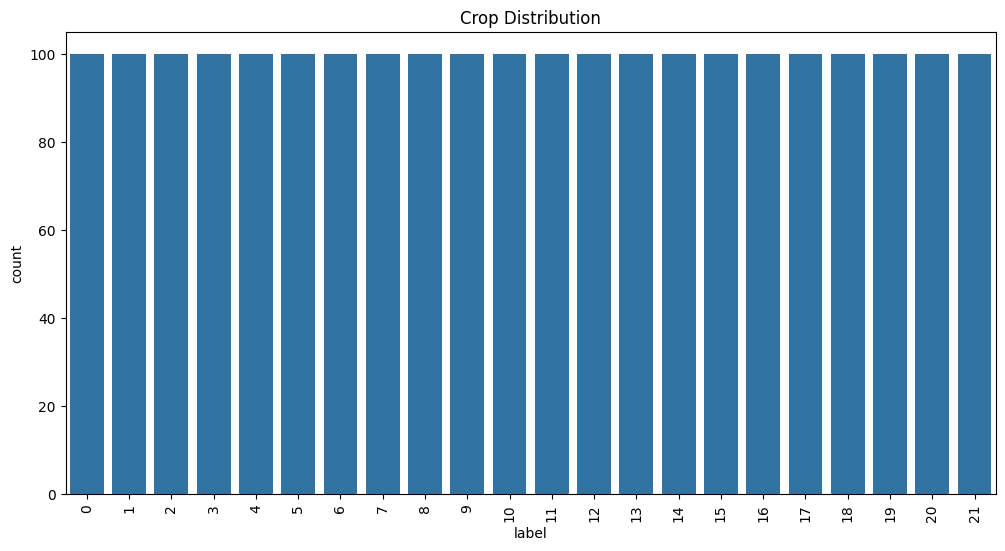

In [29]:
plt.figure(figsize=(12,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

v.) Feature vs Target Analysis

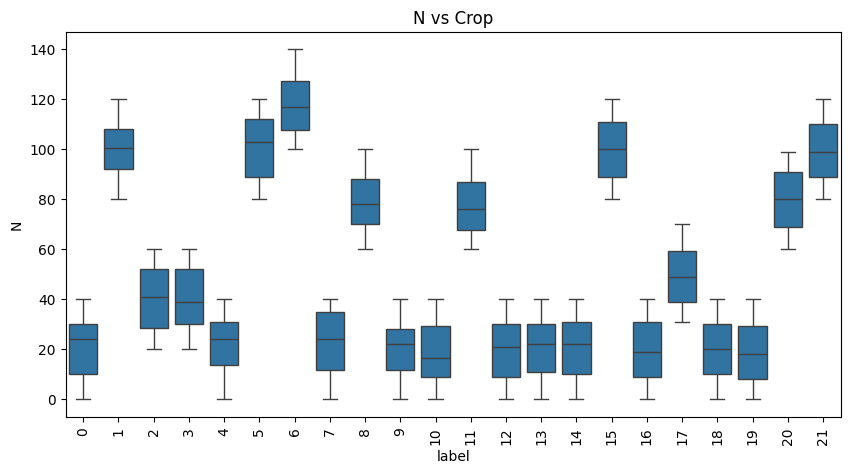

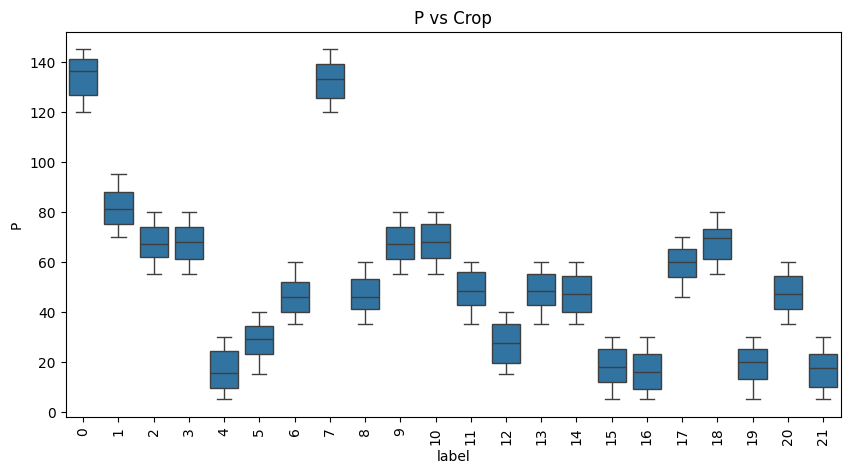

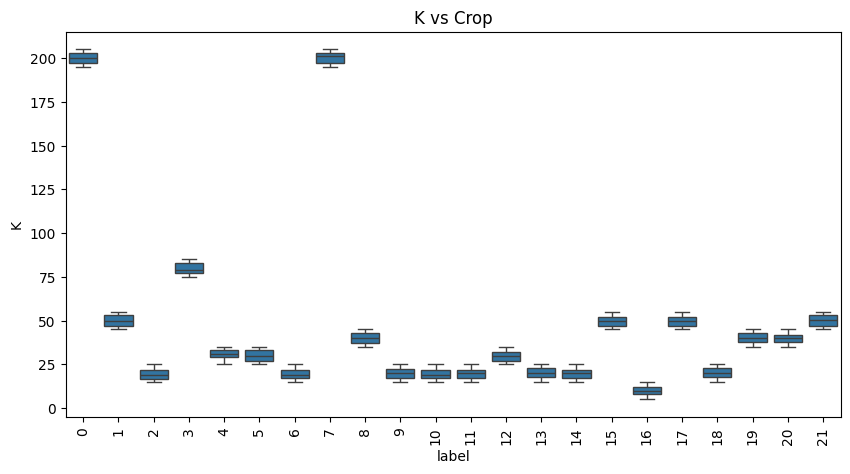

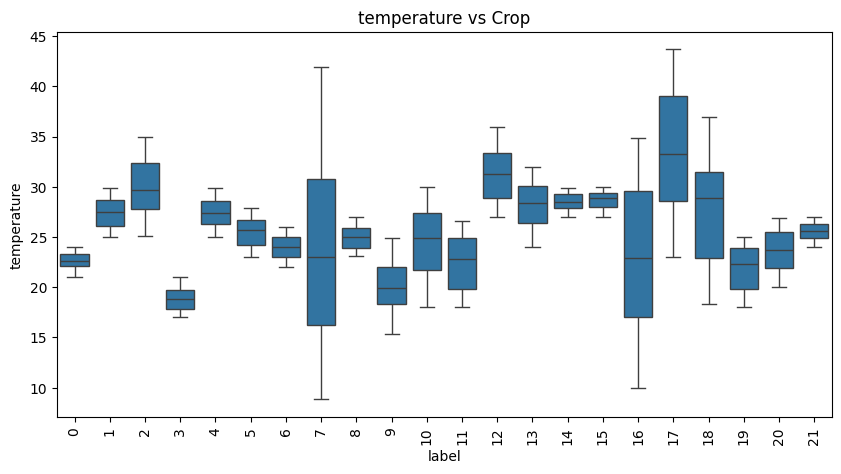

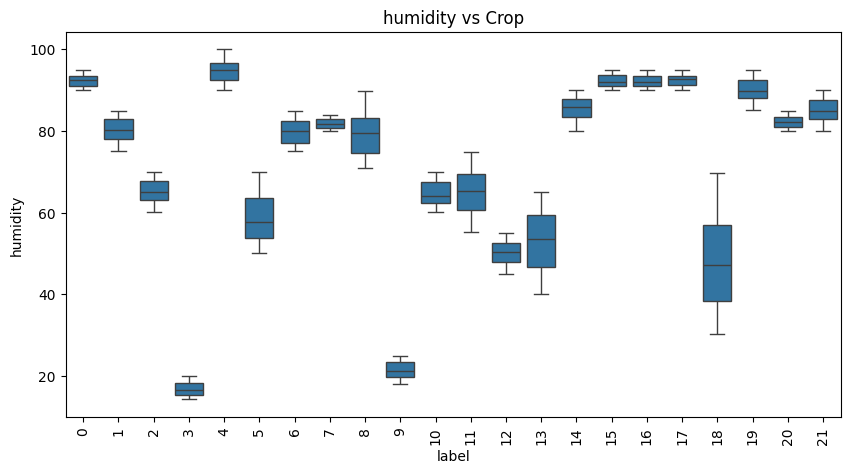

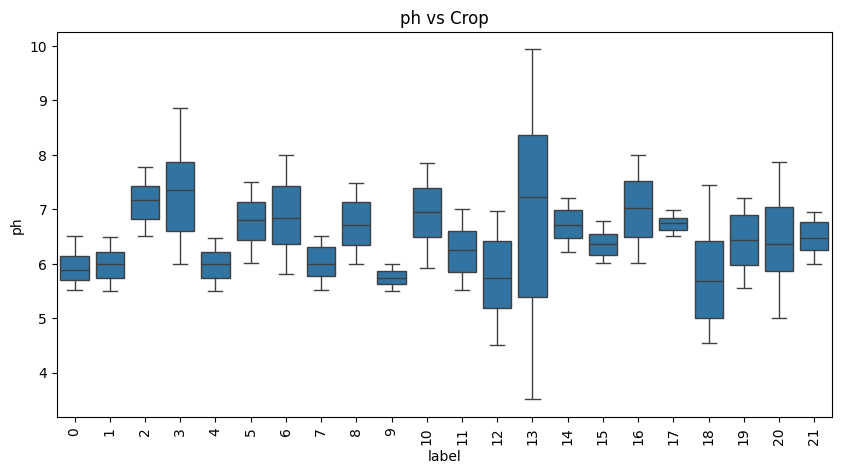

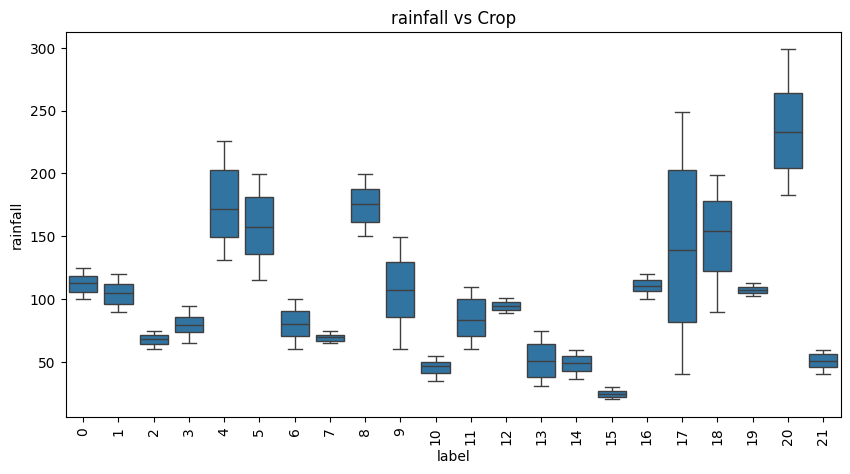

In [30]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for feature in features:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='label', y=feature, data=df)
    plt.xticks(rotation=90)
    plt.title(f"{feature} vs Crop")
    plt.show()

vi.) Outlier Detection

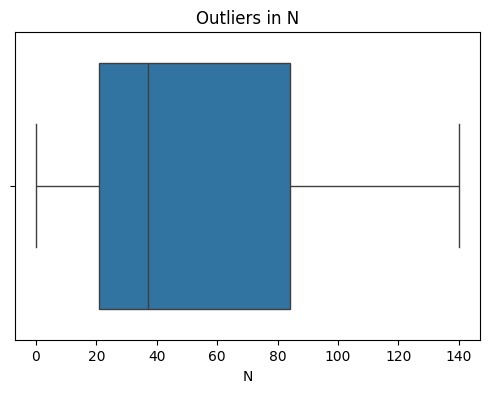

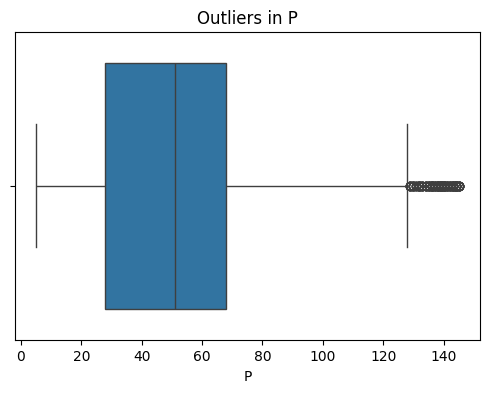

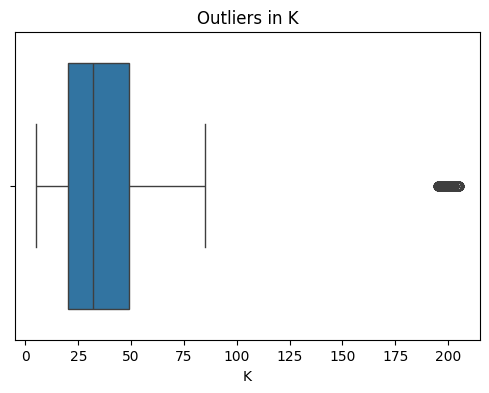

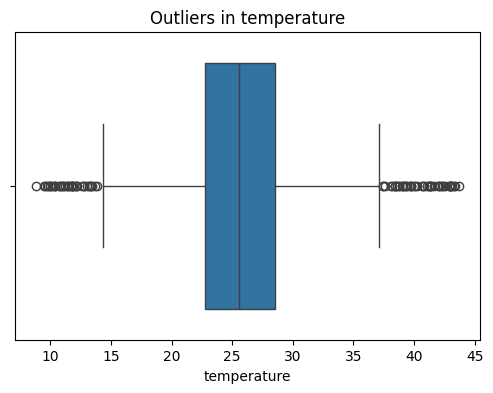

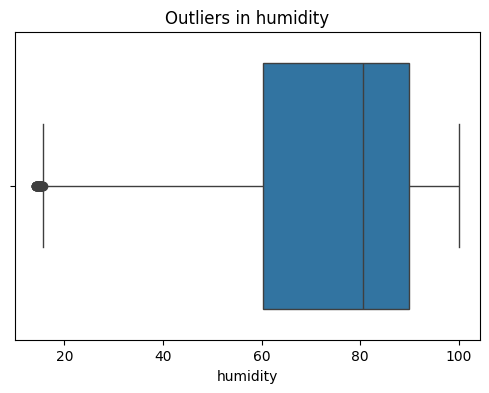

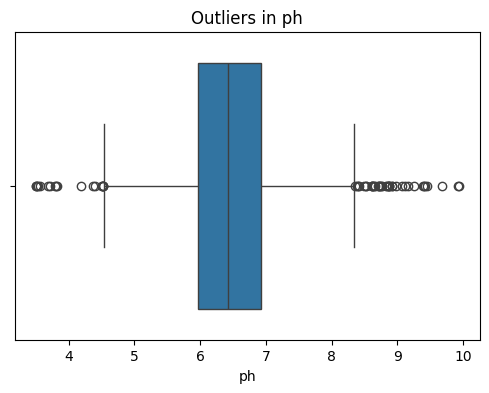

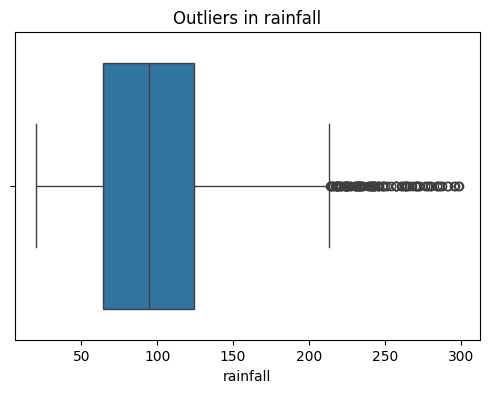

In [31]:
for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[feature])
    plt.title(f"Outliers in {feature}")
    plt.show()

Confusion Matrix

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


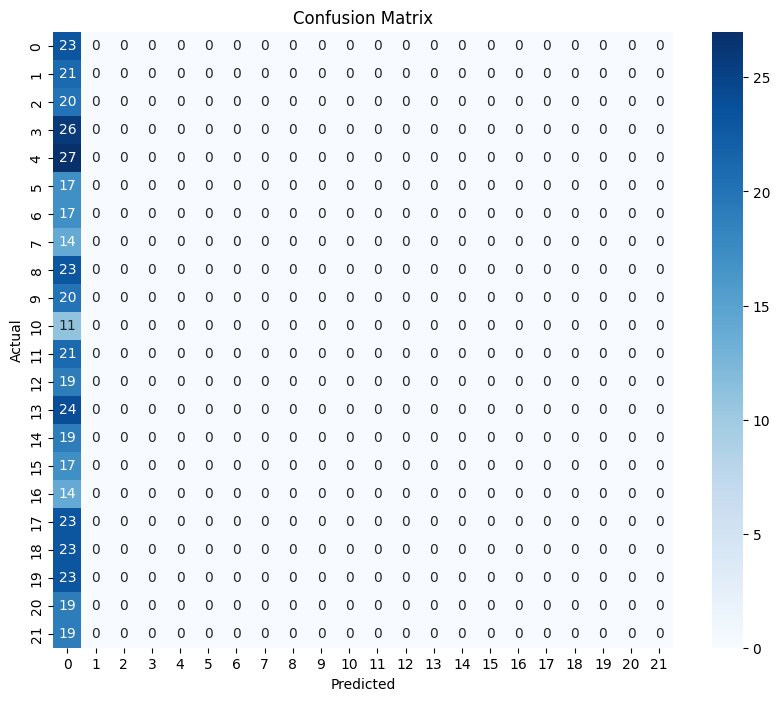

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# 🔥 SAVE
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

# **6: Feature & Target Split**

In [11]:
X = df.drop('label', axis=1)
y = df['label']

# **7: Train Test Split**

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **8: Scaling**

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **9: Train Models**

Model define

In [41]:
lr = LogisticRegression(max_iter=200, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

Model train

In [42]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

Models dictionary

In [43]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

# **10: Evaluation**

In [44]:
import pandas as pd

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.950000
1        Decision Tree  0.986364
2        Random Forest  0.993182


# **11: ROC Curve**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


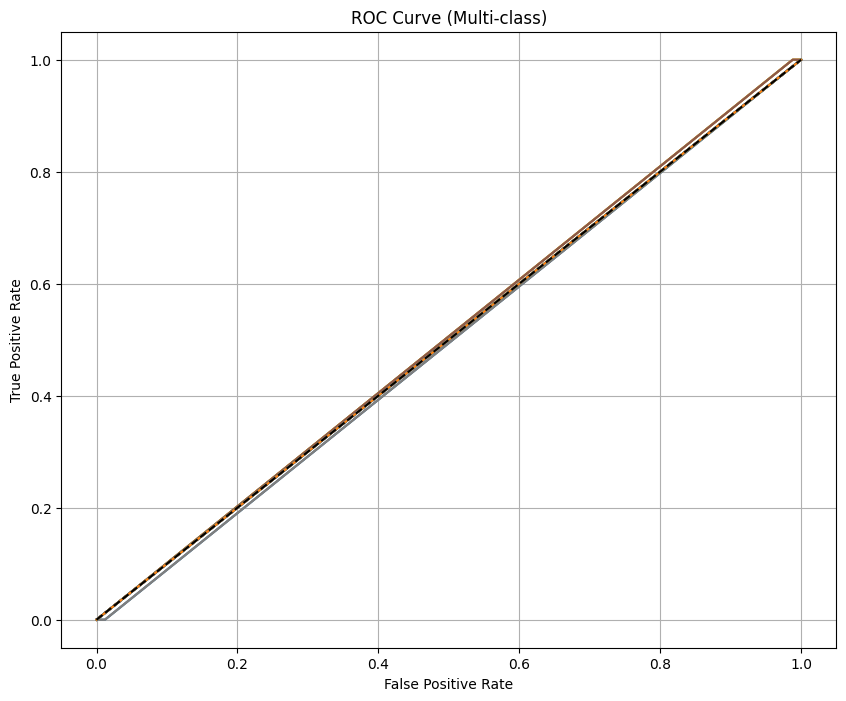

In [55]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.unique(y))

# Probability predictions
y_prob = best_model.predict_proba(X_test)

# Plot ROC curves
plt.figure(figsize=(10,8))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr)

# Diagonal line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.grid()

# 🔥 SAVE IMAGE (HIGH QUALITY)
plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')

plt.show()

# **12: Error Analysis**

Error Analysis:
- Model sometimes confuses crops with similar nutrient values
- False predictions may lead to wrong crop recommendation
- Model can be improved with more diverse dataset

# **13: Best Model**

In [16]:
best_model = rf

# **14: Feature Importance**

In [46]:
importance = best_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

print(feat_df.sort_values(by='Importance', ascending=False))

       Feature  Importance
6     rainfall    0.232518
4     humidity    0.214586
2            K    0.177664
1            P    0.142611
0            N    0.109591
3  temperature    0.068226
5           ph    0.054804


# **15: Hyperparameter Tuning**

In [47]:
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='accuracy')

# **16: Save Model**

In [48]:
import pickle

pickle.dump(best_model, open("crop_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

# **17: Prediction System**

In [20]:
model = pickle.load(open("crop_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

sample = [[90, 40, 40, 25, 80, 6.5, 200]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

print("Predicted Crop:", le.inverse_transform(prediction))

Predicted Crop: ['jute']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# **18: Case Study**


Problem:
Predict best crop based on soil and environmental conditions.

Impact:
Helps farmers choose correct crop → increases yield.

Risk:
Wrong prediction → financial loss.

Bias:
Model trained on limited dataset → may not generalize.

Future Improvement:
Add real-time weather data and more regional datasets.

In [50]:
plt.savefig("heatmap.png")

<Figure size 640x480 with 0 Axes>